# Source Patterns in the _Heliand_

I have produced a hitherto nonpublic index of Bible verses reflected in _Heliand_ verses (i.e. halflines), and I am working on similar indices for other known sources.

The present notebook identifies source distribution.

For source indexing principles, see my [notebook on unsourced sequences](https://github.com/langeslag/olg-corpus-tools/blob/main/investigations/unsourced_sequences.ipynb).

In [50]:
import re,json,copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import MultipleLocator

In [9]:
# This JSON tells us the starting verse of each fitt, so we can label our data
# by fitt and look for patterns around fitt boundaries:
with open('../heliand-fitts.json') as json_file:
    fitts_index = json.load(json_file)

# This nonpublic file is not (at present) standard TSV:
# I use extra tabs to maintain visually distinct columns.
with open('../gospel-index.tsv') as f:
    xrefs_lines = f.read().splitlines()

xrefs = dict()
for line in xrefs_lines:
    rubble = re.split(r"\t+", line, maxsplit=1)
    if len(rubble) == 2:
        xrefs[rubble[0]] = rubble[1]
    else:
        xrefs[rubble[0]] = None

In [97]:
labels = [
    'Mt',
    'Mc',
    'Lc',
    'Io',
    '1Th',
    '(Mt)',
    '(Mc)',
    '(Lc)',
    '(Io)',
    'unsourced'
]

sources = copy.copy(xrefs)
for k,v in sources.items():
    if v is None:
        sources[k] = 'unsourced'
    elif len(v) < 1:
        sources[k] = 'unsourced'
    elif v[0] == '(':
        sources[k] = v.split(' ', 1)[0] + ')'
    else:
        sources[k] =v.split(' ', 1)[0]

code_map = {src: code for code, src in enumerate(labels)}
codes = np.array([code_map[v] for v in sources.values()])
colours = ['#C7472E', '#264FA6', '#C27A13', '#355E26', '#8E4A96', '#AB7171', '#7173AB', '#FFF396', '#ABA75B', '#F2F2F2']
cmap = ListedColormap(colours[:len(labels)])
norm = BoundaryNorm(np.arange(len(labels) + 1) - 0.5, len(labels))


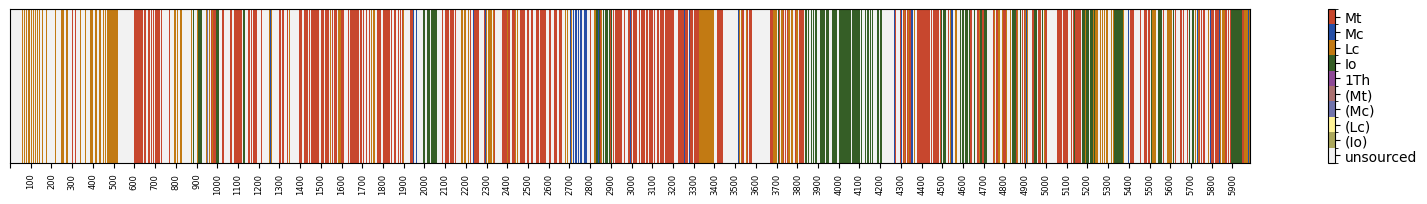

In [ ]:
fig, ax = plt.subplots(figsize=(20,2))
im = ax.imshow(
    codes[np.newaxis, :], 
    aspect="auto",
    cmap=cmap,
    norm=norm,
    interpolation="nearest")
ax.set_yticks([])
ax.set_xticks(ticks=range(1,len(codes)+1), labels=[i // 2 for i in range(1,len(codes)+1)])
ax.xaxis.set_major_locator(MultipleLocator(200))
ax.tick_params(axis="x", labelrotation=90, labelsize=6)
cbar = fig.colorbar(im, orientation='vertical', ticks=np.arange(len(labels)))
cbar.ax.set_yticklabels(labels)
cbar.ax.invert_yaxis()
plt.savefig(fname='source-patterns.svg', format='svg', bbox_inches='tight')